# Stage 7 — Statewide Application (frozen method)

Applies the method developed and frozen at Mole Creek (Stages 2, 3, 5, 6) across the whole of Tasmania at a coarser resolution. Per the plan: "the workflow was developed and tested at the Mole Creek case-study scale," then applied statewide as-is, so Stage 8 can compare the two.

**Skipped here:** the Stage 2 geology cross-check and the Stage 3 Atlas-versus-routing comparison were validation exercises at Mole Creek, so they are not repeated statewide. Only the frozen formula runs.

Karst scoring and the pressure fetch come from `src/karst.py` and `src/landuse.py`, so the Mole Creek and statewide runs share one implementation.

**Resolution:** coarsened to **100 m** (from the native 25 m DEM built in Stage 1). The full statewide pipeline runs in about 20 seconds at this resolution, so there was no need to go coarser.

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from landuse import fetch_landuse_pressure
from karst import add_karst_susceptibility, add_connectivity, add_connectivity_d8, rasterize_max, classify_fixed, aggregate_pressure_by_system
from hydro import slope_degrees, slope_risk_multiplier
from mapping import add_attribution, add_basemap, add_north_arrow, add_scalebar, plot_risk, raster_extent, risk_legend, style_map_axes

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"
TARGET_CRS = "EPSG:7855"
COARSE_RES = 100

## 7.1 Coarse statewide DEM template (100 m)

Resampled from the Stage 1 25 m mosaic (average resampling -- appropriate for downsampling continuous elevation, unlike the nearest-neighbour/mode used for categorical layers).

In [2]:
tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")

with rasterio.open(outpath / "dem_tas_EPSG7855.tif") as src:
    dst_transform, width, height = calculate_default_transform(
        src.crs, src.crs, src.width, src.height, *src.bounds, resolution=COARSE_RES
    )
    dem_coarse = np.full((height, width), src.nodata, dtype=src.dtypes[0])
    reproject(
        source=rasterio.band(src, 1), destination=dem_coarse,
        src_transform=src.transform, src_crs=src.crs,
        dst_transform=dst_transform, dst_crs=src.crs,
        src_nodata=src.nodata, dst_nodata=src.nodata,
        resampling=Resampling.average,
    )
    dem_nodata = src.nodata

template_profile = {
    "driver": "GTiff", "height": height, "width": width, "count": 1,
    "dtype": "float32", "crs": TARGET_CRS, "transform": dst_transform, "nodata": dem_nodata,
}
with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif", "w", **template_profile) as dst:
    dst.write(dem_coarse.astype("float32"), 1)

with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif") as src:
    land_masked, _ = mask(src, tasmania.geometry, crop=False, nodata=dem_nodata)
valid = land_masked[0] != dem_nodata
print(f"Coarse DEM template: {dem_coarse.shape}, {valid.sum()} valid land cells")

Coarse DEM template: (5020, 3987), 6797145 valid land cells


## 7.2 Karst susceptibility + connectivity - frozen from Stages 2 and 3, statewide

Load the complete polygon-only atlas prepared in Stage 1 (`karst_tas_EPSG7855.gpkg`) and run the shared `src/karst.py` functions across Tasmania. Connectivity is the main (D8) score: upstream cells per polygon cell from the 100 m routing run, classed at the same fixed log breaks as Mole Creek. Polygons too small to contain a 100 m cell have no routed value and keep their Atlas score (listed below). Uses `rasterize_max()` (overlap-safe) -- see Stage 2's note.

In [3]:
karst = gpd.read_file(outpath / "karst_tas_EPSG7855.gpkg")
if karst.crs != TARGET_CRS:
    karst = karst.to_crs(TARGET_CRS)

add_karst_susceptibility(karst)
add_connectivity(karst)
# Main connectivity: D8 flow routing on the 100 m DEM (03-100m notebook, shared output), log classes
d8_counts_path = outpath / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv"
if not d8_counts_path.is_file():
    raise FileNotFoundError(f"Run 03-100m-hydrological-connectivity first (or get the shared output): {d8_counts_path}")
add_connectivity_d8(karst, d8_counts_path, scheme="decades")

print("Statewide karst intensity distribution (category C occurs here, unlike Mole Creek):")
print(karst["karst_intensity"].value_counts().sort_index())
print("\nStatewide D8 connectivity class (karst polygons; unrouted = too small for a 100 m cell, keep their Atlas score):")
print(karst.loc[karst["karst_intensity"] > 0, "d8_class"].value_counts(dropna=False).sort_index())
targets = karst["karst_intensity"] > 0  # catchment-only polygons (intensity 0) are not routing targets
print("Karst polygons keeping their Atlas score:", int((karst.loc[targets, "connectivity_source"] != "d8").sum()), "of", int(targets.sum()))

intensity_raster = rasterize_max(karst, "karst_intensity", (height, width), dst_transform)
connectivity_raster = rasterize_max(karst, "connectivity", (height, width), dst_transform, dtype="float32")

Statewide karst intensity distribution (category C occurs here, unlike Mole Creek):
karst_intensity
0    924
1    260
2    329
3    758
4    330
Name: count, dtype: int64

Statewide D8 connectivity class (karst polygons; unrouted = too small for a 100 m cell, keep their Atlas score):
d8_class
1.0    146
2.0    843
3.0    349
4.0    207
NaN    132
Name: count, dtype: int64
Karst polygons keeping their Atlas score: 132 of 1677


## 7.3 Land-use pressure — frozen from Stage 5, statewide

Via `fetch_landuse_pressure()` in `src/landuse.py`: same STAC access pattern, same `PRESSURE_RECLASS` lookup. Every Level-3 class that occurs statewide is already covered by the Stage 5 table.

When downsampling (statewide, 30 m native to 100 m), the fetch uses majority/mode resampling rather than nearest-neighbour. Nearest keeps one native pixel in roughly ten and discards the rest, which can pick a non-dominant class. Mode takes the dominant one.

In [4]:
tas_wgs84 = tasmania.to_crs("EPSG:4326")
bbox = tas_wgs84.total_bounds.tolist()

pressure_aligned = fetch_landuse_pressure(bbox, 2020, outpath / "dem_tas_100m_EPSG7855.tif", target_crs=TARGET_CRS, cache_dir=inpath / "DEA_Land_Cover_Cache")
print("Pressure aligned to statewide template:", pressure_aligned.shape)

Pressure aligned to statewide template: (5020, 3987)


## 7.4 Catchment-aggregated pressure — same as Stage 6, statewide

Same reasoning as Stage 6: a per-cell product zeroes out catchment pressure wherever `karst_intensity` = 0. There are 357 distinct named systems statewide (fewer than the 1677 total features, since many features share a name). `aggregate_pressure_by_system()` runs in under 6 seconds at this scale.

**Grouping:** each name is split into spatially connected clusters (1 km gap tolerance), because pooling by `KNAME` alone would join unrelated, widely separated polygons (placeholder names like "Several"/"Various" span 100-230 km). The 454 statewide polygons with blank `KNAME` each form their own singleton system. See the `src/karst.py` docstring for the reasoning behind the 1 km threshold.

In [5]:
pressure_valid = pressure_aligned != 255
effective_pressure = aggregate_pressure_by_system(karst, pressure_aligned.astype(float), dst_transform, 255)

with_intensity = intensity_raster > 0
print(f"Mean pressure at karst cells, pixel-only: {pressure_aligned[with_intensity & pressure_valid].mean():.3f}")
print(f"Mean pressure at karst cells, catchment-aggregated: {effective_pressure[with_intensity & pressure_valid].mean():.3f}")

Mean pressure at karst cells, pixel-only: 1.305
Mean pressure at karst cells, catchment-aggregated: 1.233


## 7.5 Combine: frozen formula from Stages 4 and 6, plus the slope factor from Stage 6's update

In [6]:
intensity_norm = intensity_raster.astype(float) / 4.0
connectivity_norm = connectivity_raster.astype(float) / 3.0
intrinsic = intensity_norm * connectivity_norm

pressure_norm = np.where(pressure_valid, effective_pressure / 3.0, np.nan)
slope_factor = slope_risk_multiplier(slope_degrees(dem_coarse, dem_nodata, COARSE_RES))

risk = intrinsic * pressure_norm * slope_factor
risk_valid = valid & pressure_valid
risk = np.where(risk_valid, risk, np.nan)

print(f"Distinct statewide risk values: {len(np.unique(risk[risk_valid]))} (near-continuous now, after the pressure fix)")
print(f"Mean slope factor on karst cells: {np.nanmean(slope_factor[with_intensity & risk_valid]):.3f} (1.0 = no reduction)")

Distinct statewide risk values: 365174 (near-continuous now, after the pressure fix)
Mean slope factor on karst cells: 0.595 (1.0 = no reduction)


## 7.6 Classify and save

Via `classify_fixed()`, the same fixed 0-1 class edges as Stage 6, so a label means the same score range at both scales.

Class distribution (% of valid Tasmania land area):
  None: 6386892 cells (93.97%)
  Very Low: 85012 cells (1.25%)
  Low: 134952 cells (1.99%)
  Moderate: 140007 cells (2.06%)
  High: 37111 cells (0.55%)
  Very High: 12921 cells (0.19%)


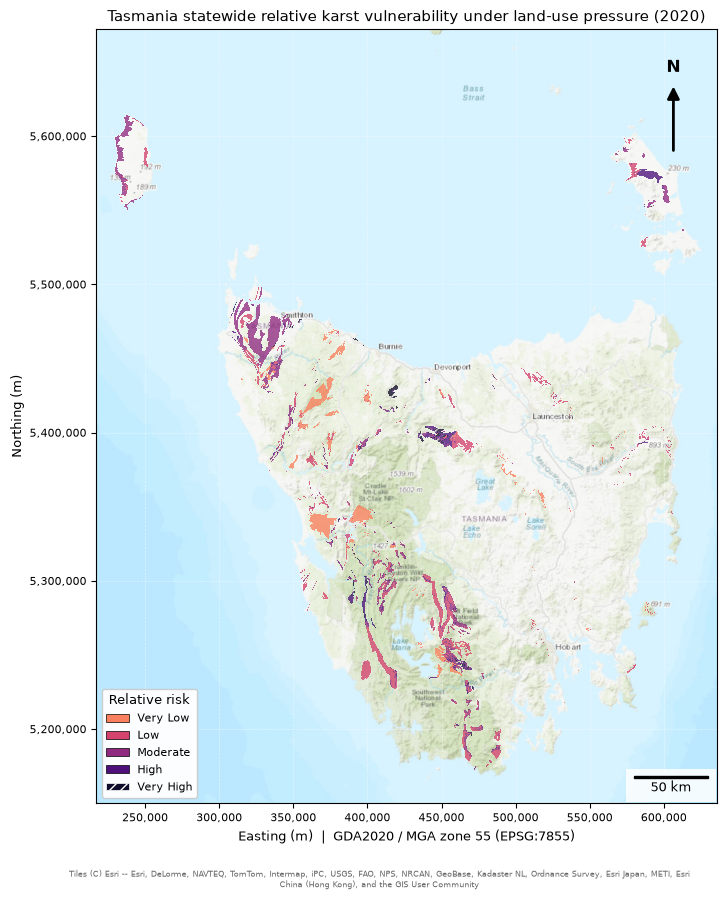

In [7]:
risk_class, edges, LABELS = classify_fixed(risk, risk_valid)

print("Class distribution (% of valid Tasmania land area):")
for i, label in enumerate(LABELS):
    n = (risk_class == i).sum()
    print(f"  {label}: {n} cells ({n/risk_valid.sum()*100:.2f}%)")

out_profile = template_profile.copy()
out_profile.update(dtype="uint8", nodata=255)
with rasterio.open(outpath / "risk_class_tas_2020_100m_EPSG7855.tif", "w", **out_profile) as dst:
    dst.write(risk_class, 1)

risk_profile = template_profile.copy()
risk_out = np.where(risk_valid, risk, template_profile["nodata"]).astype("float32")
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif", "w", **risk_profile) as dst:
    dst.write(risk_out, 1)

left, right, bottom, top = raster_extent(template_profile["transform"], risk_class.shape)
fig, ax = plt.subplots(figsize=(8, 9))
add_basemap(ax, (left, bottom, right, top), margin=10000, zoom=8)
plot_risk(ax, risk_class, template_profile["transform"])
ax.set_title("Tasmania statewide relative karst vulnerability under land-use pressure (2020)", fontsize=11)
risk_legend(ax, LABELS, loc="lower left")
style_map_axes(ax)
add_scalebar(ax, 50000, "50 km")
add_north_arrow(ax)
add_attribution(ax)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

## 7.7 Plausibility check: named karst areas, statewide

Same check as Stage 6, now over all statewide karst polygons. Aggregation is pooled: all polygons sharing a name are masked together in one operation, matching Stage 6.

In [8]:
karst_only = karst[karst["karst_intensity"] > 0].copy()

rows = []
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    for name, group in karst_only.groupby("KNAME"):
        out_image, _ = mask(src, list(group.geometry), crop=True, nodata=risk_profile["nodata"])
        vals_ = out_image[0]
        vals_ = vals_[vals_ != risk_profile["nodata"]]
        rows.append({"KNAME": name, "mean_risk": vals_.mean() if len(vals_) else np.nan, "n_pixels": len(vals_)})

named_risk = pd.DataFrame(rows).sort_values("mean_risk", ascending=False)
n_missing = named_risk["mean_risk"].isna().sum()
print(f"Named systems with zero valid pixels (too small for this raster's cell size, silently excluded from ranking): {n_missing}")
print("\nTop 15 statewide karst areas by mean risk:")
print(named_risk.head(15).to_string(index=False))

ranked = named_risk.dropna(subset=["mean_risk"]).reset_index(drop=True)
for mc_name in ["Mole Creek", "Mole Creek  (Chudleigh Hill)", "Meander - Western Creek"]:
    hit = ranked.index[ranked["KNAME"] == mc_name]
    if len(hit):
        print(f"{mc_name}: rank {hit[0] + 1} of {len(ranked)} named systems")


Named systems with zero valid pixels (too small for this raster's cell size, silently excluded from ranking): 8

Top 15 statewide karst areas by mean risk:
                           KNAME  mean_risk  n_pixels
                    Geilston Bay   0.311932         2
                    Vinegar Hill   0.283511         9
        Fairview (Redpa) (1 & 2)   0.262394        94
     Irishtown - Sedgy Creek (3)   0.248919        11
                    Gunns Plains   0.248076      2998
                   South Pindars   0.242449         3
                         Wynyard   0.231088       173
                       Nabageena   0.228216       103
                Mt Stanley Creek   0.226648        14
                   Junction Peak   0.219080        24
    Mole Creek  (Chudleigh Hill)   0.217600        13
Lower Black River - South Forest   0.202056       614
                  Franklin River   0.201015      1256
  Welcome River (1) / Port Hills   0.200659         2
                  Nicholls Range  

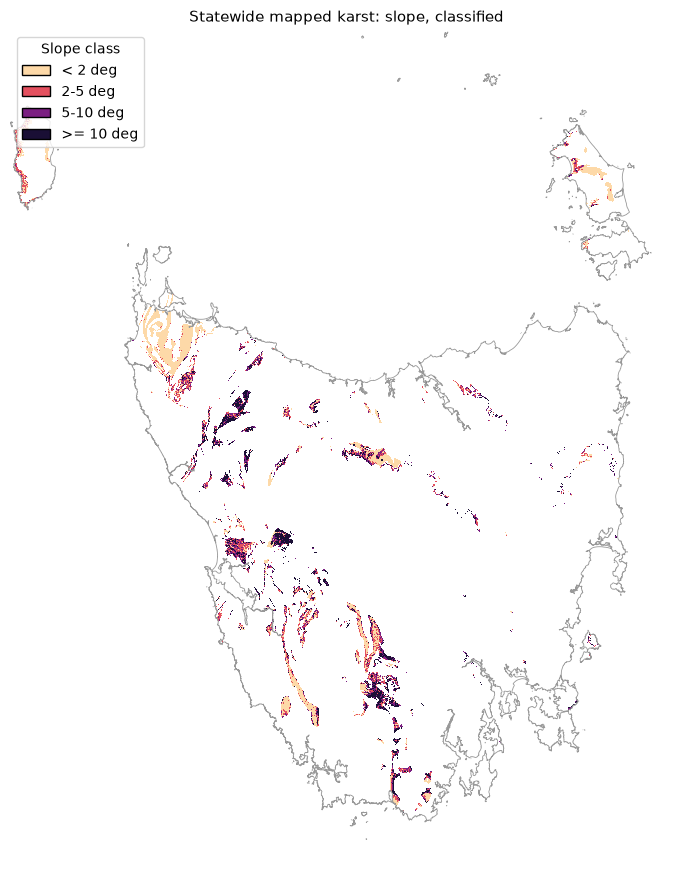

In [9]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

SLOPE_CLASS_COLOURS = ["#fdd9a8", "#e4505f", "#7b1f82", "#1a0f35"]
SLOPE_CLASS_LABELS = ["< 2 deg", "2-5 deg", "5-10 deg", ">= 10 deg"]
slope_deg = slope_degrees(dem_coarse, dem_nodata, COARSE_RES)
slope_class = np.where(np.isnan(slope_deg), np.nan, np.digitize(np.nan_to_num(slope_deg), [2, 5, 10]))
karst_slope = np.ma.masked_where(~(with_intensity & valid) | np.isnan(slope_class), slope_class)

fig, ax = plt.subplots(figsize=(8, 9))
ax.imshow(karst_slope, cmap=ListedColormap(SLOPE_CLASS_COLOURS), vmin=0, vmax=3, interpolation="nearest",
          extent=raster_extent(template_profile["transform"], slope_class.shape))
tasmania.boundary.plot(ax=ax, color="#999999", lw=0.6)
ax.legend(handles=[Patch(facecolor=c, edgecolor="black", label=l) for c, l in zip(SLOPE_CLASS_COLOURS, SLOPE_CLASS_LABELS)],
          title="Slope class", loc="upper left")
ax.set_title("Statewide mapped karst: slope, classified", fontsize=11)
ax.set_axis_off()
plt.tight_layout()
fig.savefig(Path("..") / "figures" / "slope_classified_statewide.png", dpi=200, bbox_inches="tight")
plt.show()

## What this statewide run can and can't say about Mole Creek

**Mole Creek (Chudleigh Hill)** ranks 11th of 322 named systems statewide and plain **Mole Creek** 40th, while Meander - Western Creek ranks 220th. Mole Creek is a subset of this statewide computation, using the same data and the same frozen formula, so even ranking highly shows the model is internally consistent, not that it replicates independently. An independent check would need a signal the model never saw (e.g. cave or doline density from the Karst Index Database, KID), which is out of scope here.

**Observation:** the very top of the statewide table (Geilston Bay, Vinegar Hill, Irishtown - Sedgy Creek (3)) is made of tiny systems of 2 to 11 cells at 100 m, so those means rest on very few cells. Among larger systems, several of the north-west agricultural-karst areas flagged in the earliest brainstorming for this project, before Mole Creek was chosen as the prototype, rank high (Fairview (Redpa), Gunns Plains, Wynyard, Nabageena, Lower Black River). Statewide, 21% of karst cells are Very Low, 33% Low, 34% Moderate, 9% High and 3% Very High.

**Limitation:** 132 of the 1,677 karst polygons are too small to contain a 100 m cell, so they have no routed connectivity and keep their Atlas score (Stage 3 explains the two scores).

## Stage 7 outputs

- `dem_tas_100m_EPSG7855.tif` — coarse statewide DEM template
- `risk_tas_2020_100m_EPSG7855.tif` — continuous statewide risk
- `risk_class_tas_2020_100m_EPSG7855.tif` — classified statewide risk

**Next (Stage 8):** compare this statewide-coarse output against the Mole-Creek-detailed result (Stage 6) for the Mole Creek area.